In [3]:
pip install arch

Note: you may need to restart the kernel to use updated packages.


In [4]:
# necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm
from arch import arch_model
import scipy.stats as stats
from scipy.integrate import quad
from scipy.optimize import minimize



---
---
# 1.0 Stochastic Volatility Model 

## Motivation

Financial time series, for example asset returns $r_t$, often have **time-varying volatility**. This behavior is called as **heteroskedasticity** and cannot be captured by models with constant variance such as the classical AR(1) model. The **Stochastic Volatility (SV) model** solves the problem by modeling volatility itself as a **stochastic process**.

## Model Structure

The basic SV model consists of two equations:

### 1. **Measurement Equation**

We assume the return is driven by a time-varying volatility:

$$
r_t = \sigma_t \cdot \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0,1)
$$

Now define the **log-variance**:

$$
h_t = \log(\sigma_t^2) = 2 \cdot \log(\sigma_t)
\quad \Rightarrow \quad \sigma_t = \exp\left( \frac{1}{2} h_t \right)
$$

Inserting this into the return equation gives the final form of the measurement equation:

$$
r_t = \exp\left( \frac{1}{2} h_t \right) \cdot \varepsilon_t
$$

- $r_t$: observed return at time $t$  
- $h_t$: latent log-variance (log-volatility)  
- $\varepsilon_t$: standard normal shock  
- $\sigma_t^2 = \exp(h_t)$: time-varying variance

### 2. **State Equation (Log-Volatility)**

$$
h_t = \phi h_{t-1} + \eta_t, \quad \eta_t \sim \mathcal{N}(0, \sigma_\eta^2)
$$

- $\phi \in (0,1)$: persistence parameter → how dependent the current volatility is on the previous one  
- $\sigma_\eta$: volatility of the log-volatility process → how much the volatility fluctuates  
- $\eta_t$: innovation term → random shock in volatility

This AR(1) process ensures that the log-volatility evolves smoothly over time and remains stationary when $|\phi| < 1$.

## Stationary Distribution

Because $h_t$ follows an AR(1) process, its **stationary variance** is:

$$
\text{Var}(h_t) = \frac{\sigma_\eta^2}{1 - \phi^2}
$$

Therefore, the initial state $h_0$ comes from the stationary distribution:

$$
h_0 \sim \mathcal{N}\left(0, \frac{\sigma_\eta^2}{1 - \phi^2} \right)
$$

## Simulation Process

1. Draw $h_0$ from the stationary distribution.
2. Generate the AR(1) process $h_t$ for $t = 1, \dots, T$.
3. Generate the returns $r_t$ using time-varying volatility with $r_t = \exp(0.5 h_t) \cdot \varepsilon_t$.

## Conclusion

The SV model provides a better framework for modeling **volatile financial time series**, making it possible to have **stochastic** volatility.  
SV models introduce an additional source of randomness, offering **greater flexibility** in capturing the behaviour of volatility.


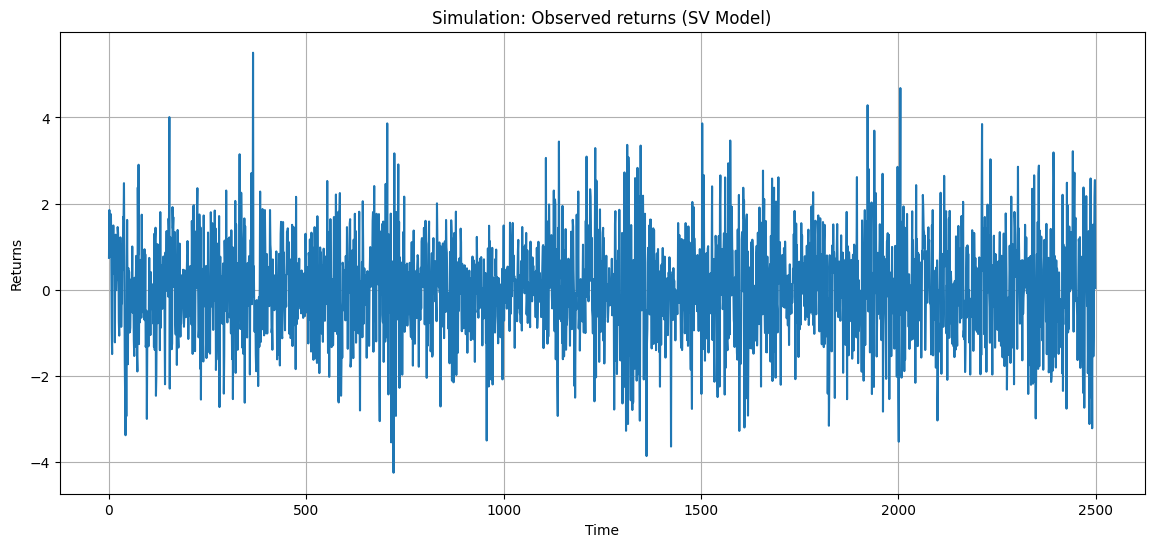

In [5]:
np.random.seed(1234)

# Sample size
T = 2500

# parameters
phi = 0.95     # persistence has to be between 0 and 1
sigma_eta = 0.2  # Volatility of log-vol
sigma = 1.0    

# latent log volatility is a timeseries with Samplesize T
h_true = np.zeros(T)


#Initialize h_true with the stationary distribution (stationary variance)
h_true[0] = np.random.normal(loc=0, scale=sigma_eta / np.sqrt(1 - phi**2))

#  AR(1) process rekursion
for t in range(1, T):
    h_true[t] = phi * h_true[t-1] + np.random.normal(0, sigma_eta)

x = np.random.normal(0, 1, T)  # normal-distributed noise
r = sigma * np.exp(0.5 * h_true) * x  # Returns with SV

# Plot observed returns
plt.figure(figsize=(14, 6))
plt.plot(r)
plt.title('Simulation: Observed returns (SV Model)')
plt.xlabel('Time')
plt.ylabel('Returns')
plt.grid(True)
plt.show()


## 1.1 Interpretation of the Simulated Time Series

The plot above shows a realization of returns $r_t$ generated from a **Stochastic Volatility  model**. In this idea, the returns are given by:

$$
r_t = \sigma_t \cdot x_t = \exp\left( \frac{1}{2} h_t \right) \cdot x_t, \quad x_t \sim \mathcal{N}(0,1),
$$

where $h_t$ is the latent log-volatility process that is defined according to the AR(1) equation:

$$
h_t = \phi h_{t-1} + \eta_t, \quad \eta_t \sim \mathcal{N}(0, \sigma_\eta^2).
$$

### Visual Observations:
- The plot reflects **volatility clustering**, a key-concept of real financial time series. This means that periods of high volatility (chaotic market phases) and low volatility (relaxed phases) tend to cluster together.
- The underlying process $h_t$ induces **heteroskedasticity**. time-varying conditional variance, while keeping the unconditional distribution of returns around zero.

This simulation provides an idea into how stochastic volatility models can replicate empirical characteristics of asset returns, such as **fat tails** and **time-varying risk**.


---
---
# 2.0 Kalman Filter: Theoretical Background

The **Kalman filter** gives us a mathematical solution to a fundamental problem:  
> *How can we estimate something that we cannot observe directly, using noisy and uncertain information over time?*

The core idea is to **combine prior expectations (from a model)** with **new, noisy observations**, weighting each according to how reliable they are.  
The filter runs **recursively**: it predicts the system’s next state, then updates that prediction using incoming data. Over time, it learns and adapts, making our estimate better, step by step.

It is especially useful when:

- The system is **dynamically** (changes over time),
- Observations are **imperfect or incomplete**,
- We want **real-time estimates** without reprocessing the full data history.

---

## Model Structure

A **linear state-space model** consists of:

### 1. **State Equation)**

$$
x_t = \Phi x_{t-1} + \eta_t, \quad \eta_t \sim \mathcal{N}(0, Q)
$$

- $x_t$: latent and unobserved state at time $t$  
- $\Phi$: state transition parameter phi --> if phi is close to 1, the persistence ist high 
- $Q$: process noise covariance  
- $\eta_t$: process noise – represents uncertainty or new shocks in the system

### 2. **Observation Equation (Measurement Model)**

$$
y_t = a + B x_t + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, H)
$$

- $y_t$: observed measurement at time $t$  
- $a, B$: measurement parameters (intercept and loading)  
- $H$: observation noise variance  
- $\varepsilon_t$: measurement error – reflects errors in observations

---

## Kalman Filter Procedure

### **1. Prediction Step (Time Update)**

- Predicted state:
  $$
  \hat{x}_t^- = \Phi \cdot \hat{x}_{t-1}
  $$
- Predicted variance:
  $$
  P_t^- = \Phi P_{t-1} \Phi + Q
  $$

 *What we expect about the state before seeing the new data.*

### **2. Update Step --> Measurement Correction**

- **Innovation and adaption:**
  $$
  v_t = y_t - (a + B \cdot \hat{x}_t^-)
  $$

  ⟶ Difference between actual and predicted measurement is called residuum.

- **Innovation variance:**
  $$
  F_t = B^2 P_t^- + H
  $$

  ⟶ Uncertainty of the innovation, combining model and measurement noise.

- **Kalman Gain:**
  $$
  K_t = \frac{B P_t^-}{F_t}
  $$

  ⟶ A weight that determines how much to trust the new data.  
  Larger when measurements are precise (small $H$). The formula minimizes the MSE.

- **Updated state estimate:**
  $$
  \hat{x}_t = \hat{x}_t^- + K_t v_t
  $$

- **Updated variance:**
  $$
  P_t = P_t^- - K_t B P_t^-
  $$

 *The updated estimate balances model predictions and observations based on their respective uncertainties.*

---

## Log-Likelihood

The **log-likelihood** tells us how good the model explains the observed data under the assumption of normal-distr. noise. It measures the probability of observing the actual data sequence $(y_1, \dots, y_T)$ given the current model parameters.

For each time $t$, the likelihood contribution is:

$$
\log \mathcal{L}_t = -\frac{1}{2} \left[ \log(2\pi) + \log(F_t) + \frac{v_t^2}{F_t} \right]
$$

Summing over time we get the total log-likelihood:

$$
\log \mathcal{L} = \sum_{t=1}^T \log \mathcal{L}_t
$$

This is especially useful for **Maximum Likelihood Estimation**:  
We can adjust parameters like $\Phi$, $Q$, $H$, etc., to **maximize** this likelihood. In practice, this allows us to fit the state-space model to the data and learn its dynamics directly from observations.

---

## Summary

The Kalman filter:

- Provides **optimal linear estimates** in Gaussian systems  
- **Recursively** updates beliefs in real time  
- Provides a **likelihood function** for parameter estimation

It is a foundational tool in **dynamic modeling and inference**, with applications across many disciplies (for example **finance**).


In [6]:
def kalman_filter(y, a, B, Phi, H, Q, xi, P, return_loglike=False):
    """
    
    Parameter explanation
    y : observed data
    a, B : y = a + B*r (linear transformation)
    Phi : auto-regressive coefficient (Persistence: todays returns depend from prior returns)
    xi :  initial state mean
    P : initial state variance
    H : Varianz Messrauschen
    Q : Varianz Zustandsrauschen

    """
    T = len(y)
    loglike = 0
    
    post_mean = np.zeros(T)
    post_var = np.zeros(T)
    prior_mean = np.zeros(T)
    prior_var = np.zeros(T)
    
    for t in range(T):
        # Prediction step
        if t == 0: # Initialize
            prior_mean[t] = Phi * xi  
            prior_var[t] = Phi * P * Phi + Q  
        else:
            prior_mean[t] = Phi * post_mean[t-1]
            prior_var[t] = Phi * post_var[t-1] * Phi + Q
        
        # Update parameter calculation
        y_pred = a + B * prior_mean[t]
        F = B * prior_var[t] * B + H
        K = prior_var[t] * B / F
        
        post_mean[t] = prior_mean[t] + K * (y[t] - y_pred)
        post_var[t] = prior_var[t] - K * B * prior_var[t]
        
        # log-likelihood for normal distrib.
        loglike += -0.5 * (np.log(2*np.pi) + np.log(F) + (y[t]-y_pred)**2/F)
    
    if return_loglike:
        return -loglike
    else:
        return post_mean, post_var, prior_mean, prior_var

# 2.1 Harvey Transformation and Kalman Filtering of Stochastic Volatility

## Motivation

In the Stochastic Volatility (SV) model the latent volatility process $h_t$ enters the model in a **not linear** way through the measurement equation:

$$
r_t = \exp\left( \frac{1}{2} h_t \right) \cdot x_t, \quad x_t \sim \mathcal{N}(0, 1).
$$

This implies that the variance of $r_t$ is:

$$
\text{Var}(r_t \mid h_t) = \exp(h_t),
$$

which makes **inference challenging** because standard Kalman filtering techniques only work with **linear models**.

## Harvey Transformation

To linearize the model and so preparing it for the use of the Kalman filter, we perform the **Harvey transformation**:

### Step: Take the logarithm of squared returns

$$
y_t = \log(r_t^2) = \log\left( \exp(h_t) \cdot x_t^2 \right) = h_t + \log(x_t^2).
$$

Since $x_t^2 \sim \chi^2(1)$ (chi-squared with 1 degree of freedom), the expectation of $\log(x_t^2)$ is:

$$
\mathbb{E}[\log(x_t^2)] \approx -1.27,
$$

and its variance is:

$$
\text{Var}[\log(x_t^2)] \approx \frac{\pi^2}{2}.
$$

Because of that, we can rewrite the transformed model as:

### Linearized Measurement Equation

$$
y_t = a + B h_t + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, H)
$$

with:

- $a = \mathbb{E}[\log(x_t^2)] \approx -1.27$ (bias correction),
- $B = 1$,
- $H = \text{Var}[\log(x_t^2)] = \frac{\pi^2}{2}$.

The state equation still is unchanged:

$$
h_t = \phi h_{t-1} + \eta_t, \quad \eta_t \sim \mathcal{N}(0, \sigma_\eta^2).
$$

## Why Is This Useful?

The Harvey transformation allows us to:

- **Linearize** the nonlinear SVM,
- Apply the **Kalman filter** to estimate the hidden volatility process $h_t$,
- Compute **filtered (posterior) and predicted (prior) estimates** of volatility.

This provides a efficient, statistical method for extracting hidden volatility from observed returns.

## Visual Interpretation

- The **first plot** compares the true latent volatility $\exp(h_t/2)$ with the estimated volatility $\exp(\hat{h}_t/2)$.
- The **second plot** overlays returns with symmetric volatility bounds based on the estimated state.



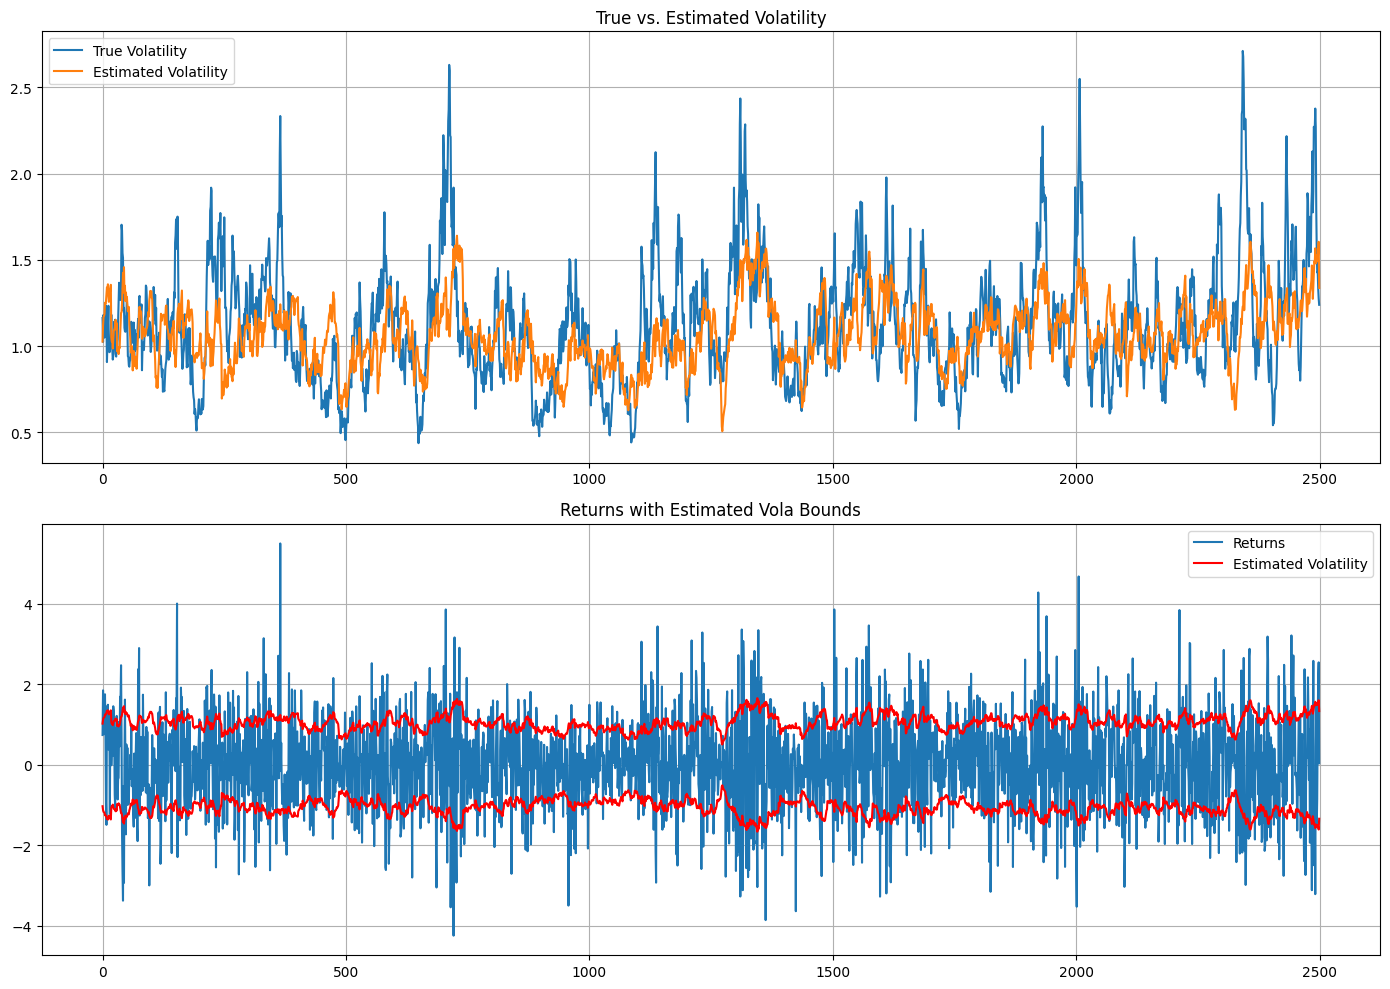

In [7]:
# Harvey-Transformation der simulierten Renditen
y = np.log(r**2)  # transform to make it lineare
a = -1.27         # y = a + h_t + error / a= -1,27 konstant Bias (X^2 distribution) 
B = 1             
Phi = phi
H = np.pi**2 / 2  # transformed measurement variance
Q = sigma_eta**2  # state_error variance

# Initiate stationary-distribution
xi = 0
P = sigma_eta**2 / (1 - phi**2)  # ???

# Kalman Filter 
post_mean, post_var, prior_mean, prior_var = kalman_filter(
    y, a, B, Phi, H, Q, xi, P, return_loglike=False
)



plt.figure(figsize=(14, 10))

# true vs. estimated variance
plt.subplot(2, 1, 1)
plt.plot(np.exp(h_true/2), label='True Volatility')
plt.plot(np.exp(post_mean/2), label='Estimated Volatility')
plt.title('True vs. Estimated Volatility')
plt.legend()
plt.grid(True)

# returns with vola bounds
plt.subplot(2, 1, 2)
plt.plot(r,  label='Returns')
plt.plot(np.exp(post_mean/2), 'r', label='Estimated Volatility')
plt.plot(-np.exp(post_mean/2), 'r')
plt.title('Returns with Estimated Vola Bounds')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

---
---
# 3.0 Maximum Likelihood Estimation (MLE) for the SV Model

To estimate the parameters $\theta = (\phi, \sigma_\eta, \sigma)$ of the SVM, we maximize the **likelihood** of the observed data.

After the **Harvey transformation**:

$$
y_t = \log(r_t^2) \approx a + h_t + \varepsilon_t, \quad \varepsilon_t \sim \mathcal{N}(0, H),
$$

we get a **linear model**, which allows the use of the **Kalman filter** to compute the **log-likelihood** of the data.

### Objective:

Find parameters that **maximize the log-likelihood**:

$$
\hat{\theta} = \arg \max_{\theta} \; \log \mathcal{L}(\theta \mid y).
$$

Now, we **minimize the negative log-likelihood** using numerical optimization. This provides statistically efficient estimates .



In [8]:
# Define the objective function for MLE
y = np.log(r**2)

def kalman_filter_obj(params, y):
    """

    phi : persistence parameter (must be between 0 and 1)
    sigma_eta : volatility of log-volatility process (must be positive)
    sigma : scale parameter (must be positive)
    y : observed data (Harvey transformed returns)

    
    Return: negative log likelihood of the observations given the parameters
    """

    
    phi, sigma_eta, sigma = params

    # Define parameter constraints
    if (0 < phi < 1) and (sigma_eta > 0) and (sigma > 0): # sigmas have to be positive for logical reasons

        # Expected log variance under stationary distribution
        mu_logh = -1.27
        a = np.log(sigma**2) - mu_logh

        # Initial state mean/var
        xi = 0
        P = sigma_eta**2 / (1 - phi**2)

        # Model parameters
        B = 1.0                   # Coefficient in measurement equation
        Phi = phi                # AR(1) persistence param
        H = (np.pi**2) / 2       # Measurement noise variance
        Q = sigma_eta**2         # State noise variance

        # Apply Kalman filter and compute log-likelihood
        loglike = kalman_filter(y, a, B, Phi, H, Q, xi, P, return_loglike=True)

    else:
        # If violation --> make loglike super big
        loglike = np.inf

    return loglike

# 3.1 Parameter Estimation via Maximum Likelihood

To estimate the parameters of the stochastic volatility model, we use **numerical optimization** form the **scipy-lib** to minimize the **negative log-likelihood**.

- First guess according to task description: $\phi = 0.9$, $\sigma_\eta = 0.3$, $\sigma = 1.2$
- Parameter bounds for correctness ($0 < \phi < 1$) and positivity ($\sigma_\eta > 0$, $\sigma > 0$)
- Optimization is done using the **L-BFGS-B algorithm**, good approach for bounded problems

The result ist the **Maximum Likelihood Estimates** of the parameters phi, sigma_eta and sigma:

$$
\hat{\phi}, \hat{\sigma}_\eta, \hat{\sigma}
$$

These are compared to the true simulation values to evaluate estimation accuracy.


In [9]:
# First parameter start-point
initial_guess = [0.9, 0.3, 1.2]  # [phi, sigma_eta, sigma]

# define bounds
bounds = [(0.001, 0.999), (1e-6, None), (1e-6, None)] # 1e-6 numerical 'trick'

# use scipy.optimize to find the most likeli parameters
result = minimize(kalman_filter_obj, x0=initial_guess, args=(y,),
                  bounds=bounds, method='L-BFGS-B')

# optimized parameters
phi_hat, sigma_eta_hat, sigma_hat = result.x

print(f"Optimization successful: {result.success}")
print(f"Estimated phi = {phi_hat:.4f}, true phi = {phi:.4f}")
print(f"Estimated sigma = {sigma_hat:.4f}, true sigma = {sigma:.4f}")
print(f"Estimated sigma_eta = {sigma_eta_hat:.4f}, true sigma_eta = {sigma_eta:.4f}")



Optimization successful: True
Estimated phi = 0.9519, true phi = 0.9500
Estimated sigma = 0.3108, true sigma = 1.0000
Estimated sigma_eta = 0.1643, true sigma_eta = 0.2000


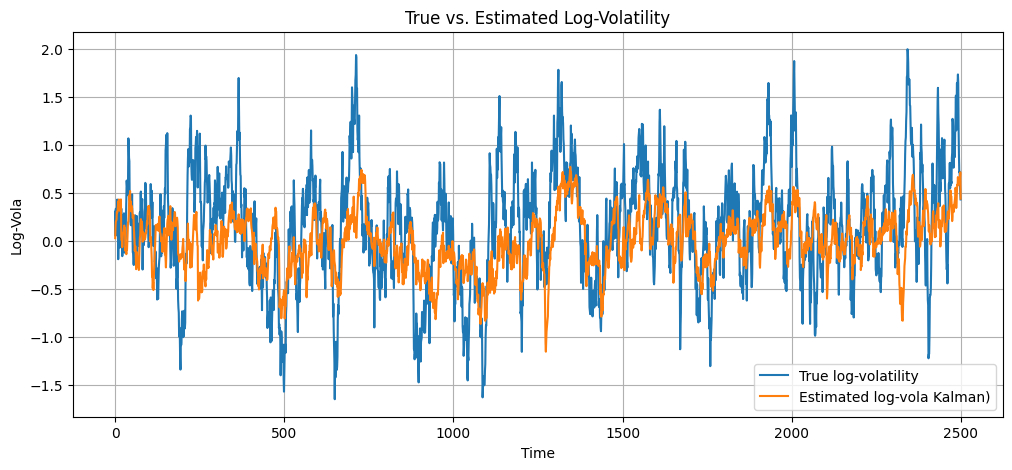

In [10]:
# Expected log of squared standard normal
a = -1.27


a_est = np.log(sigma_hat**2) - a

# Initial state average and variance
xi_0 = 0
P_0 = sigma_eta_hat**2 / (1 - phi_hat**2)


H_val = (np.pi**2) / 2 # Zustandsrauschen
Q_val = sigma_eta_hat**2 # Messrauschen

# Run Kalman filter with estimated parameters
post_mean_estimated, post_var_estimated, prior_mean_estimated, prior_var_estimated = kalman_filter(
    y=y,
    a=a_est,
    B=1.0,
    Phi=phi_hat,
    H=H_val,
    Q=Q_val,
    xi=xi_0,
    P=P_0
)

# true vs. estimated log-volatility --> Plot
plt.figure(figsize=(12, 5))
plt.plot(h_true, label='True log-volatility')
plt.plot(post_mean_estimated,  label='Estimated log-vola Kalman)')
plt.legend()
plt.title('True vs. Estimated Log-Volatility')
plt.xlabel('Time')
plt.ylabel('Log-Vola')
plt.grid(True)
plt.show()



# 3.2 Interpretation: True vs. Estimated Log-Volatility

The plot compares the **true log-volatility** (blue ts) with the **estimated log-volatility** calculated by using the **Kalman filter** (orange ts) over the 2500 observations.

### Observations and Explanations:

- The Kalman estimate tracks the **general trend and low-frequency dynamics** of the true log-volatility quite well.
- However, the estimate is **smoother** than the true series. This is expected and makes sense:
  - The Kalman filter acts as a **denoiser**, balancing model dynamics with noisy observations.
  - High-frequency spikes and dips in the true process are partially filtered out.
- In periods of higher volatility (for example in the end the end), the Kalman estimate adjusts upwards, capturing persistent shifts quite well.

### Conclusion:

The Kalman filter provides a **useful real-time estimate** of latent log-volatility. While it cannot capture every sharp movement due to noise suppression, it effectively approximates the underlying process with less variance and good responsiveness to persistent changes.


---
---
# 4.0 EGARCH(1,1) Model: Motivation and Interpretation

The **Exponential GARCH (EGarch)** model is a popular version of GARCH that captures **asymmetries and nonlinearities** in financial volatility.

### Model Structure

The EGARCH(1,1) model specifies the log of conditional variance as:

$$
\log(\sigma_t^2) = \omega + \beta \log(\sigma_{t-1}^2) + \alpha \left( \frac{|r_{t-1}|}{\sigma_{t-1}} - \sqrt{\frac{2}{\pi}} \right)
$$

This ensures:
- **Non-negativity** of variance without explicit parameter constraints
- Ability to capture **leverage effects** (volatility reacts differently to positive vs. negative shocks)
- A **log-linear form** that is compatible with normally distributed returns

### Purpose

The EGARCH model is used to:
- Estimate **conditional volatility** $\sigma_t$ from observed returns $r_t$
- Provide an alternative to stochastic volatility models for measuring **time-varying risk**
- Generate **risk measures** such as Value-at-Risk 

### Comment Code

- `arch_model(..., vol='EGARCH')` fits an EGARCH(1,1) model to returns $r_t$
- The **estimated conditional standard deviations** are stored in `garch_vol`
- The log-volatility series $\log(\sigma_t^2)$ is done via $2 \log(\sigma_t)$
- The plot visualizes:
  - **Standardized residuals**: $r_t / \sigma_t$
  - **Estimated volatility**: how it evolves over time

EGARCH can be used as a flexible benchmark for volatility modeling in **Quant-finance**.


                       Zero Mean - EGARCH Model Results                       
Dep. Variable:                      y   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                     EGARCH   Log-Likelihood:               -3839.40
Distribution:                  Normal   AIC:                           7684.79
Method:            Maximum Likelihood   BIC:                           7702.26
                                        No. Observations:                 2500
Date:                Sat, Jun 14 2025   Df Residuals:                     2500
Time:                        10:44:14   Df Model:                            0
                              Volatility Model                              
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega          0.0248  9.277e-03      2.676  7.458e-03 [6.

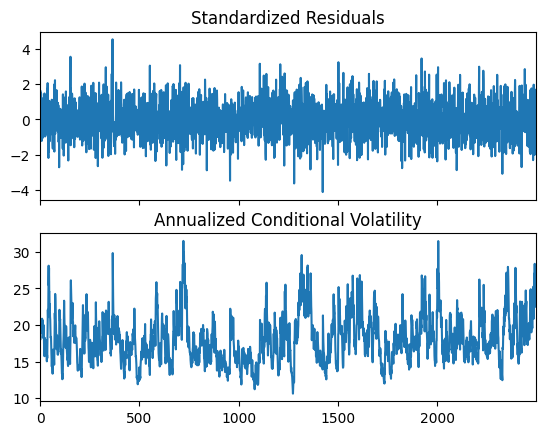

In [11]:
#  EGARCH(1,1) model
def run_egarch_model(r):
    # EGARCH(1,1) model
    am = arch_model(r, vol='EGARCH', p=1, o=0, q=1, dist='normal', mean='zero')  # EGARCH(1,1)
    egarch_result = am.fit(disp='off')

    garch_vol = egarch_result.conditional_volatility  # calculate cond. vola

    # new variable for log_vola of the garch
    garch_log_vol = np.log(garch_vol**2)

    print(egarch_result.summary())  # summary table

    # Plot standardized residuals and conditional vola
    fig = egarch_result.plot(annualize='D')
    plt.show()

    return egarch_result, garch_vol, garch_log_vol

# Call the function
egarch_result, garch_vol, garch_log_vol = run_egarch_model(r)


# 4.1 Interpretation of EGARCH(1,1) Estimation Results

### Model Summary

The estimated model is an **EGARCH(1,1)** with a **zero mean** and normally distributed innovations. It is fitted to a time series of 2500 returns using **maximum likelihood estimation**.

- **Log-Likelihood**: $-3839.40$  
- **AIC**: $7684.79$  
- **BIC**: $7702.26$  

These information params can be used to compare alternative models — **lower values stand for a better fit**.

---


### Residual Diagnostics

- The **standardized residuals** appear centered close to 0 with no obvious autocorrelation.
- The **conditional volatility** plot shows us a clear **volatility clustering**, a typical thing of **financial returns**.

Annualized volatility fluctuates between approximately **10% and 30%**, which is **realistic for asset returns**.

---

### Conclusion

The EGARCH(1,1) model:

- Accurately captures **time-varying volatility** and **persistence**.
- Provides a flexible framework through the **log-variance specification**, allowing for **asymmetries** .
- Is suitable for further use in **risk modeling**, such as Value-at-Risk and Expected Shortfall  analysis.



# 5.0 Value-at-Risk (VaR) and Expected Shortfall (ES)

### Motivation

In financial risk management, we are often interested in the potential for **extreme negative losses** also called **black swans**. Two important risk measures are:

- **Value-at-Risk (VaR):** the threshold loss level such that the probability of surpassing it is $\alpha$ (5% is very common).
- **Expected Shortfall (ES):** the **expected loss** given that the loss **exceeds the VaR** —- a more conservative measure of tail risk.

These measures are especially useful for:

- **Regulatory risk assessment**
- **Portfolio risk monitoring**
- **Stress testing**

---

### Assumptions

Under the assumption that returns are **conditionally normally distributed** (is often false in finance) with time-varying standard deviation $\sigma_t$, we can develop formulas for VaR and ES.

---

### Formulas

Let $z_\alpha$ be the **$\alpha$-quantile** of the standard normal distribution:

$$
z_\alpha = \Phi^{-1}(\alpha)
$$

Let $\phi(z_\alpha)$ be the **probability density** at $z_\alpha$:

$$
\phi(z_\alpha) = \frac{1}{\sqrt{2\pi}} e^{-z_\alpha^2/2}
$$

Then, for each time $t$, we compute:

- **Value-at-Risk (VaR):**

$$
\text{VaR}_t = z_\alpha \cdot \sigma_t
$$

This gives the $\alpha$-level loss threshold. For example, at $\alpha = 0.05$, $z_\alpha \approx -1.645$.

- **Expected Shortfall (ES):**

$$
\text{ES}_t = -\sigma_t \cdot \frac{\phi(z_\alpha)}{\alpha}
$$

This computes the **expected loss in the worst $\alpha \cdot 100\%$ of cases**, and is always more negative than VaR.

---

### Interpretation

- $\text{VaR}_t$ answers: *"What is the maximum expected loss at confidence level $(1-\alpha)$?"*
- $\text{ES}_t$ answers: *"If we exceed the VaR threshold, how bad could the loss be on average?"*


In [12]:
def VaR_ES(std_dev, alpha=0.05):
    """
    var: Value at Risk time-series
    Value at Risk (VaR) estimates the maximum loss a portfolio is likely to experience over a given time period at a certain confidence level

    es: Expected Shortfall time-series
    Expected Shortfall (ES) measures the average loss in the worst-case scenarios beyond the VaR threshold.

    alpha: confidence level indicates the probability that a statistical estimate will contain the true value or outcome in repeated samples or scenarios
    """

    # Quantile  from the standard normal distribution
    x0 = norm.ppf(alpha)

    # Manual calculation of standard normal PDF at x0
    phi_x0 = np.exp(-0.5 * x0**2) / np.sqrt(2 * np.pi)

    # Compute Value at Risk
    var = x0 * std_dev

    # Compute Expected Shortfall
    es = -std_dev * (phi_x0 / alpha)

    return var, es



In [17]:

alpha = 0.05 # confidence level has to be 5%

kf_std_dev = np.exp(0.5 * post_mean_estimated)

# Calculate VaR and ES using our function above for Kalman Data
VaR_KF, ES_KF = VaR_ES(kf_std_dev, alpha)

# Calculate VaR und ES using our function above for GARCH Data
VaR_EGARCH, ES_EGARCH = VaR_ES(garch_vol, alpha)


---
---
# 6.0 Coverage Ratio

The **coverage ratio** tells us how often observed returns $r_t$ fall below the estimated Value-at-Risk  threshold:

$$
\text{Coverage Ratio} = \frac{1}{T} \sum_{t=1}^T \mathbb{1}_{\{ r_t < \text{VaR}_t \}}
$$

### Idea

It measures the **accuracy** of a VaR model. It compares the **actual proportion of losses** exceeding the predicted VaR to the expected level $\alpha$ (in our example 5%).

- If the model is well-calibrated: $\text{Coverage} \approx \alpha$
- Too many overruns $\Rightarrow$ VaR is **underestimated**
- Too few overruns $\Rightarrow$ VaR is **too conservative**

That is why, it is a key-metric in **backtesting** Value-at-Risk models.


In [18]:
def coverage_ratio(returns, var_series):
    """
    if the returns are more negativ than the calculated volatility (returns < var_arr) the coverage ratio goes up
    """

    counter = 0
    for r, v in zip(returns, var_series):
        if r < v:
            counter += 1
    return counter / len(returns)



Kalman VaR coverage = 6.48% (expected 5.00%)
EGARCH VaR coverage = 5.00% (expected 5.00%)


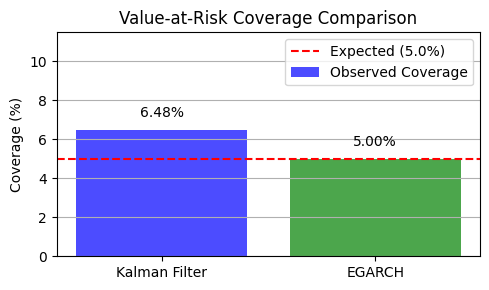

In [19]:
# Calculate ratios using the function coverage_ratio for Kalman and for Garch
cov_kf = coverage_ratio(r, VaR_KF)
cov_garch = coverage_ratio(r, VaR_EGARCH)

#  results
print(f"Kalman VaR coverage = {100 * cov_kf:.2f}% (expected {alpha*100:.2f}%)")
print(f"EGARCH VaR coverage = {100 * cov_garch:.2f}% (expected {alpha*100:.2f}%)")


models = ['Kalman Filter', 'EGARCH']
coverage = [cov_kf, cov_garch]
expected = [alpha, alpha] 

plt.figure(figsize=(5, 3))
bars = plt.bar(models, [100 * c for c in coverage], color=['blue', 'green'], alpha=0.7, label='Observed Coverage')
plt.axhline(y=alpha*100, color='red', linestyle='--', label=f'Expected ({alpha*100:.1f}%)')

for bar, val in zip(bars, coverage):
    plt.text(bar.get_x() + bar.get_width()/2, 100 * val + 0.5,
             f"{100 * val:.2f}%", ha='center', va='bottom')

plt.title('Value-at-Risk Coverage Comparison')
plt.ylabel('Coverage (%)')
plt.ylim(0, max(100 * max(coverage), alpha * 100) + 5)
plt.legend()
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()



# 6.1 Interpretation of the coverage ratio

- The **EGARCH model** exactly matches the expected coverage, showing us that it is a well-calibrated VaR forecast.
- The **Kalman SVM** slightly **underestimates risk**, as the actual surpassing rate (6.48%) is higher than the nominal level (5%).

This suggests that the EGARCH model may provide more accurate tail risk forecasts in our example.


---
---
# 7.0 Comparation Plots: Volatility and Risk Measure Comparison

The following plots give us a visual comparison between the **Kalman filter-based stochastic volatility  model** and the **EGARCH(1,1) model**.

### Plot 1: Log-Volatility Estimates

This plot compares:

- The **true latent log-volatility** $h_t$ used in the simulation,
- The **estimated log-volatility** from the Kalman filter,
- The **log-volatility** implied by the EGARCH model.

It helps evaluate how good each method estimates the true, unobserved volatility behaviour.

---

### Plot 2: Returns vs. Kalman-based VaR and ES

This shows:

- Actual returns $r_t$,
- Value-at-Risk (VaR) and Expected Shortfall (ES) computed using the **Kalman-filtered volatility**.

It shows whether the **risk estimates effectively capture extreme losses** based on the SV model.

---

### Plot 3: Returns vs. EGARCH-based VaR and ES

Similar to Plot 2, but using volatility estimates from the **EGARCH(1,1)** model.

This visual comparison allows us to see:

- How conservative each model is in estimating tail risk,
- Whether the models react appropriately to periods of high volatility.

These diagnostics are super important for validating and comparing **risk forecasting models**.


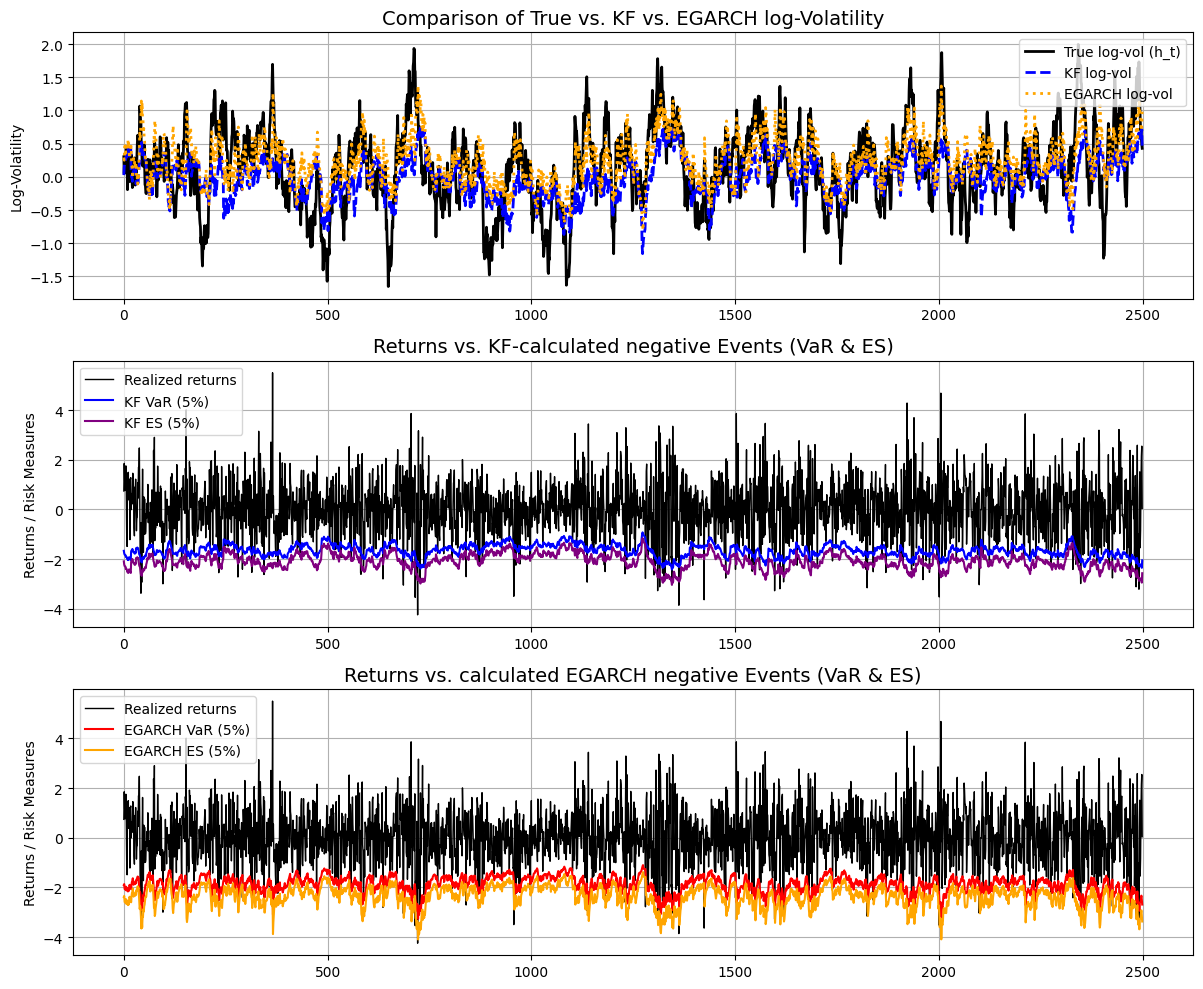

In [21]:
plt.figure(figsize=(12, 10))

# Compare log-volatility estimations
plt.subplot(3, 1, 1)
plt.plot(h_true, label='True log-vol (h_t)', color='black', lw=2)
plt.plot(post_mean_estimated, label='KF log-vol', color='blue', lw=2, linestyle='--')
plt.plot(garch_log_vol, label='EGARCH log-vol', color='orange', lw=2, linestyle=':')
plt.title('Comparison of True vs. KF vs. EGARCH log-Volatility', fontsize=14)
plt.legend(loc='upper right')
plt.grid(True)
plt.ylabel('Log-Volatility')

# Plot2: Returns vs. KF VaR and ES
plt.subplot(3, 1, 2)
plt.plot(r, color='black', label='Realized returns', lw=1)
plt.plot(VaR_KF, color='blue',  label='KF VaR (5%)')
plt.plot(ES_KF, color='purple',  label='KF ES (5%)')
plt.title('Returns vs. KF-calculated negative Events (VaR & ES)', fontsize=14)
plt.legend(loc='best')
plt.grid(True)
plt.ylabel('Returns / Risk Measures')

#  Plot 3: Returns r vs. EGarch VaR / ES
plt.subplot(3, 1, 3)
plt.plot(r, color='black', label='Realized returns', lw=1)
plt.plot(VaR_EGARCH, color='red', label='EGARCH VaR (5%)')
plt.plot(ES_EGARCH, color='orange',  label='EGARCH ES (5%)')
plt.title('Returns vs. calculated EGARCH negative Events (VaR & ES)', fontsize=14)
plt.legend(loc='best')
plt.grid(True)
plt.ylabel('Returns / Risk Measures')

plt.tight_layout()
plt.show()


# 7.1 Interpretation of Volatility and Risk Forecasting Plots

### Plot 1: Log-Volatility Comparison

The top picture compares:

- The **true latent log-volatility** $h_t$ (black),
- The **Kalman filter estimate** (blue dashed),
- The **EGARCH(1,1) estimate** (orange dotted).

Both models follow the general volatility dynamics, but the Kalman filter tracks more closely during high- and low-volatility phases.

---

### Plot 2: Returns vs. Kalman-Based VaR and ES

The middle picture shows:

- Realized returns $r_t$ (black),
- Kalman-based **VaR** (blue) and **ES** (purple).

These lines provide dynamic left-tail risk estimates. Periods with spikes in returns often come together with wider risk bands, showing **increased uncertainty**.

---

### Plot 3: Returns vs. EGARCH-Based VaR and ES

The bottom picture repeats the structure for EGARCH:

- EGARCH-based **VaR** (red) and **ES** (orange) are smoother but still reactive to volatility clusters.
- Risk measures adjust dynamically, showing reasonable tail risk control.

### Summary

Both models provide meaningful estimates of time-varying volatility and tail risk, with the Kalman filter reacting more sharply to volatility shifts.
